In [2]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 62.3 MB/s eta 0:00:00


# Continuous Wave (CW) G2 Correlation Function Simulation

In [2]:
import numpy as np
import pylab as plt
import qutip as qt
from qutip import *

In [3]:
# ==========================================
# 1. PHYSICAL PARAMETERS (The "Space" Specs)
# ==========================================

# Environment
temperature_kelvin = 20.0  # We would modify this

# A. Radioactive Decay | Space Noise Parameter
lifetime_ns = 1.0 # Radiative lifetime (~1 ns)
gamma_decay = 1.0 / lifetime_ns

# B. Radiation-Induced Dephasing | Space Noise Parameter
gamma_dephase_thermal = 0.05 * (temperature_kelvin / 4.0)**2
gamma_dephase_radiation = 0.2
gamma_total_dephase = gamma_dephase_thermal + gamma_dephase_radiation

# C. Stray Light "Pumping" Rate | Space Noise Parameter
# This represents background photons (Sun/Earth) absorbed by the QD.
# 0.0 means perfect darkness. 0.2 means significant light leakage.
gamma_stray_light = 0.15 * gamma_decay

# Drive Power (Rabi Frequency)
# For CW excitation, we keep it comparable to the decay rate to see oscillations
rabi_freq = 2.0 * gamma_decay

print(f"--- Simulation Parameters ---")
print(f"Temperature: {temperature_kelvin} K")
print(f"Excitation Power: {rabi_freq:.3f} GHz")

print("\n")

print(f"--- Space Noise Simulation Parameters ---")
print(f"Decaying Rate: {gamma_decay:.3f} GHz")
print(f"Dephasing (thermal + radiation) Rate: {gamma_total_dephase:.3f} GHz")
print(f"Stray Light Pumping: {gamma_stray_light:.3f} GHz")

print("\n")

--- Simulation Parameters ---
Temperature: 20.0 K
Excitation Power: 2.000 GHz


--- Space Noise Simulation Parameters ---
Decaying Rate: 1.000 GHz
Dephasing (thermal + radiation) Rate: 1.450 GHz
Stray Light Pumping: 0.150 GHz




In [4]:
 # ==========================================
# 2. HAMILTONIAN & DYNAMICS (QuTiP)
# ==========================================

# Operators for a 2-level system
g = qt.basis(2, 0) # Ground
e = qt.basis(2, 1) # Excited
sigma_minus = g * e.dag() # Lowering operator (photon emission)
sigma_plus  = e * g.dag() # Excitation (g -> e)
sigma_z = e * e.dag() - g * g.dag()

# Hamiltonian (H = H0 + H_drive)
# H = hbar * (Omega/2) * (sigma_x)
# (Rotating Frame, Detuning = 0 for simplicity)
H = 0.5 * rabi_freq * (sigma_minus + sigma_minus.dag())

# Collapse Operators (Noise)
c_ops = []
c_ops.append(np.sqrt(gamma_decay) * sigma_minus) # 1. Standard Radiative Decay (Good: Emits our photon)
c_ops.append(np.sqrt(gamma_total_dephase) * sigma_z) # 2. Total Dephasing (Bad: Destroys indistinguishability)
c_ops.append(np.sqrt(gamma_stray_light) * sigma_plus) # 3 Incoherent Excitation (The "Stray Light" Operator)

In [5]:
# ==========================================
# 3. CALCULATE g2(tau)
# ==========================================

rho_ss = qt.steadystate(H, c_ops)
taus = np.linspace(0, 25.0, 200)

# first calculate the occupation number as a function of time
n = mesolve(H, rho_ss, taus, c_ops, [sigma_minus.dag() * sigma_minus]).expect[0]

# calculate the correlation function G2 and normalize with n(0)n(t) to
# obtain g2
G2 = correlation_3op_1t(H, rho_ss, taus, c_ops, sigma_minus.dag(), sigma_minus.dag()*sigma_minus, sigma_minus)
g2 = G2 / (n[0] * n)

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


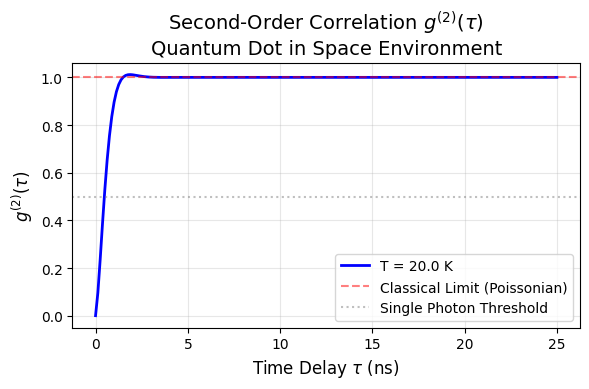

In [6]:
# ==========================================
# 4. PLOTTING THE "DIP"
# ==========================================

plt.figure(figsize=(6, 4))

# Plot the simulated data
plt.plot(taus, np.real(g2), 'b-', linewidth=2, label=f'T = {temperature_kelvin} K')

# Add a visual reference for "Classical Light" limit
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Classical Limit (Poissonian)')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Single Photon Threshold')

plt.title(f'Second-Order Correlation $g^{{(2)}}(\\tau)$\nQuantum Dot in Space Environment', fontsize=14)
plt.xlabel('Time Delay $\\tau$ (ns)', fontsize=12)
plt.ylabel('$g^{(2)}(\\tau)$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.tight_layout()
plt.show()

# Pulsed Excitation Simulation

In [5]:
import numpy as np
import pylab as plt
import qutip as qt
from qutip import *

In [6]:
# ==========================================
# 1. PHYSICAL PARAMETERS (The "Space" Specs)
# ==========================================

# Environment
temperature_kelvin = 20.0  # We would modify this

# A. Radioactive Decay | Space Noise Parameter
lifetime_ns = 1.0 # Radiative lifetime (~1 ns)
gamma_decay = 1.0 / lifetime_ns

# B. Radiation-Induced Dephasing | Space Noise Parameter
gamma_dephase_thermal = 0.05 * (temperature_kelvin / 4.0)**2
gamma_dephase_radiation = 0.2
gamma_total_dephase = gamma_dephase_thermal + gamma_dephase_radiation

# C. Stray Light "Pumping" Rate | Space Noise Parameter
# This represents background photons (Sun/Earth) absorbed by the QD.
# 0.0 means perfect darkness. 0.2 means significant light leakage.
gamma_stray_light = 0.15 * gamma_decay

# Drive Power (Rabi Frequency)
# For CW excitation, we keep it comparable to the decay rate to see oscillations
rabi_freq = 2.0 * gamma_decay

print(f"--- Simulation Parameters ---")
print(f"Temperature: {temperature_kelvin} K")
print(f"Excitation Power: {rabi_freq:.3f} GHz")

print("\n")

print(f"--- Space Noise Simulation Parameters ---")
print(f"Decaying Rate: {gamma_decay:.3f} GHz")
print(f"Dephasing (thermal + radiation) Rate: {gamma_total_dephase:.3f} GHz")
print(f"Stray Light Pumping: {gamma_stray_light:.3f} GHz")

print("\n")

--- Simulation Parameters ---
Temperature: 20.0 K
Excitation Power: 2.000 GHz


--- Space Noise Simulation Parameters ---
Decaying Rate: 1.000 GHz
Dephasing (thermal + radiation) Rate: 1.450 GHz
Stray Light Pumping: 0.150 GHz




In [7]:
# ==========================================
# 2. DEFINE THE PULSE FUNCTION
# ==========================================

# Pulse Parameters (The "Clock")
period_ns = 10.0          # We fire a laser pulse every 10 ns (100 MHz rate)
pulse_width = 0.2         # Width of the laser pulse (sigma) in ns
pulse_center = 2.0        # First pulse arrives at t=2.0 ns

# The "Pi-Pulse" Amplitude
# To flip the qubit perfectly from G -> E, Area = pi.
# For Gaussian: Area = Amp * width * sqrt(2*pi)
# Therefore: Amp = pi / (width * sqrt(2*pi))
pi_pulse_amp = np.pi / (pulse_width * np.sqrt(2 * np.pi))

print(f"--- Pulsed Mode Specs ---")
print(f"Repetition Rate: {1/period_ns*1e3:.1f} MHz")
print(f"Pulse Amplitude: {pi_pulse_amp:.3f} GHz (Rabi Freq)")

# This function tells QuTiP how the laser intensity changes with time
def laser_pulse_shape(t, args):
    # A Gaussian envelope
    envelope = np.exp(-((t - args['center'])**2) / (2 * args['width']**2))
    return envelope

# Dictionary of arguments to pass to the solver
pulse_args = {'center': pulse_center, 'width': pulse_width}

--- Pulsed Mode Specs ---
Repetition Rate: 100.0 MHz
Pulse Amplitude: 6.267 GHz (Rabi Freq)


In [14]:
 # ==========================================
# 3. HAMILTONIAN & DYNAMICS (QuTiP)
# ==========================================

# Operators for a 2-level system
g = qt.basis(2, 0) # Ground
e = qt.basis(2, 1) # Excited
sigma_minus = g * e.dag() # Lowering operator (photon emission)
sigma_plus  = e * g.dag() # Excitation (g -> e)
sigma_z = e * e.dag() - g * g.dag()

# Hamiltonian (H = H0 + H_drive)
# H = hbar * (Omega/2) * (sigma_x)
# (Rotating Frame, Detuning = 0 for simplicity)
H_drive = 0.5 * pi_pulse_amp * (sigma_minus + sigma_minus.dag())

# Total Hamiltonian (Time Dependent Format)
# H = [Static_Part, [Operator, Function]]
# Since we have no static detuning, the first part is Zero operator (or just omitted if 0)
H = [0*sigma_z, [H_drive, laser_pulse_shape]]

# Collapse Operators (Noise)
c_ops = []
c_ops.append(np.sqrt(gamma_decay) * sigma_minus) # 1. Standard Radiative Decay (Good: Emits our photon)
c_ops.append(np.sqrt(gamma_total_dephase) * sigma_z) # 2. Total Dephasing (Bad: Destroys indistinguishability)
c_ops.append(np.sqrt(gamma_stray_light) * sigma_plus) # 3 Incoherent Excitation (The "Stray Light" Operator)

In [29]:
 # ==========================================
# 4. MASTER EQUATION SOLVER (QuTiP)
# ==========================================

# We use 'mesolve' (Master Equation Solver)
tlist = np.linspace(0, 10, 500)
psi0 = g # Start in Ground State

# We want to track the population of the Excited State (probability of emission)
result = mesolve(H, psi0, tlist, c_ops, [e * e.dag()], args=pulse_args)

# Integrate the emission rate over time to get total photons
# Rate = Gamma * Probability_Excited
n_emitted = np.trapz(gamma_decay * result.expect[0], tlist)

print(f"--- THE VERDICT ---")
print(f"Total Photons Emitted per Pulse: {n_emitted:.4f}")

if n_emitted > 1.05:
    print("WARNING: Multi-photon emission detected! (Pulse too long/strong)")
    print("Result: NOT a clean Single Photon Source.")
elif n_emitted < 0.8:
    print("WARNING: Pulse too weak. Low efficiency.")
else:
    print("SUCCESS: ~1 Photon per pulse. It is a quantum Single Photon Source.")

--- THE VERDICT ---
Total Photons Emitted per Pulse: 1.6820
Result: NOT a clean Single Photon Source.


/tmp/ipython-input-3686244021.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  n_emitted = np.trapz(gamma_decay * result.expect[0], tlist)


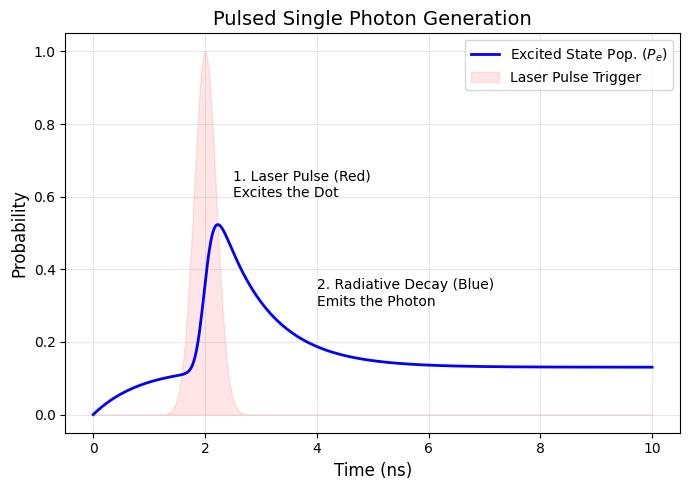

In [30]:
# ==========================================
# 5. VISUALIZATION
# ==========================================
excited_population = result.expect[0]

plt.figure(figsize=(7, 5))

# Plot 1: The Excited State Population (The System Response)
plt.plot(tlist, excited_population, 'b-', linewidth=2, label='Excited State Pop. ($P_e$)')

# Plot 2: The Laser Pulse (Visual Reference only)
# We calculate the shape manually just for plotting
laser_profile = [laser_pulse_shape(t, pulse_args) for t in tlist]
plt.fill_between(tlist, laser_profile, color='red', alpha=0.1, label='Laser Pulse Trigger')

plt.title('Pulsed Single Photon Generation', fontsize=14)
plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Add text to explain the physics
plt.text(2.5, 0.6, "1. Laser Pulse (Red)\nExcites the Dot", fontsize=10)
plt.text(4.0, 0.3, "2. Radiative Decay (Blue)\nEmits the Photon", fontsize=10)

plt.tight_layout()
plt.show()